In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, linregress
from scipy.optimize import curve_fit

In [70]:
%matplotlib inline

## Definde Functions

In [71]:
def linear_funct(x, intercept, slope):
    return intercept + x * slope

def linear_fit(x, y, dy=None):
    '''
    :return: intercept, gradient, d_inter, d_gradient
    '''
    with open('outf3.csv', 'w') as f:
        for a, b, c in zip(x, y, dy):
            f.write(f"{a};{b};{c}")
    a_fit,cov=curve_fit(linear_funct ,x ,y ,sigma=dy, absolute_sigma=True)
    return a_fit[0], a_fit[1], np.sqrt(cov[0][0]), np.sqrt(cov[1][1])

def density_plot(x, y, xlbl=None, ylbl=None):
    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

def density_plot_spacing(x, y, xpts, xspans=None, xlbl=None, ylbl=None):

    pts_x = []
    pts_y = []
    unc_y = []
    for i, xp in enumerate(xpts):
        if i == 0:
            xlim_min = -np.inf
            xlim_max = (xpts[0] + xpts[1])/2
        elif i == len(xpts)-1:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = np.inf
        else:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = (xpts[i+1] + xpts[i])/2

        locvals = []
        for xval, yval in zip(x, y):
            if xlim_min < xval < xlim_max:
                locvals.append(yval)

        if len(locvals) > 0:
            pts_x.append(xp)
            pts_y.append(np.median(locvals))
            unc_y.append(np.sqrt(np.pi * (2 * len(locvals) + 1) / (4 * len(locvals))) * np.std(locvals) / np.sqrt(len(locvals)))


    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

    ax.plot(pts_x, pts_y, c='red', label='median')
    ax.scatter(pts_x, pts_y, c='red', marker='x', s=50)
    ax.errorbar(pts_x, pts_y, yerr=unc_y, c='red')

    plt.legend()

def histo_evolution(x, y, xpts, xspans=None, xlbl=None, ylbl=None, bins=200):

    fig, ax = plt.subplots()
    keypts_x = []
    keypts_y = []
    kpy_sig = []

    mind = np.amin([abs(xpts[i] - xpts[i+1]) for i in range(len(xpts) - 1)])

    for i, xp in enumerate(xpts):
        if xspans is None:
            if i == 0:
                xlim_min = -np.inf
                xlim_max = (xpts[0] + xpts[1])/2
            elif i == len(xpts)-1:
                xlim_min = (xpts[i-1] + xpts[i])/2
                xlim_max = np.inf
            else:
                xlim_min = (xpts[i-1] + xpts[i])/2
                xlim_max = (xpts[i+1] + xpts[i])/2
        else:
            xlim_min = xp - xspans
            xlim_max = xp + xspans

        locvals = []
        for xval, yval in zip(x, y):
            if xlim_min < xval < xlim_max:
                locvals.append(yval)

        # print(locvals)
        if len(locvals) > 0:
            loc_hist = np.histogram(locvals, bins=bins)
            # print(loc_hist)
            histo_y = np.array(loc_hist[0], dtype=float)
            histo_x = np.array([(loc_hist[1][i] + loc_hist[1][i+1])/2 for i in range(len(loc_hist[1])-1)])
            histo_y/=np.amax(histo_y)
            histo_y *= mind
            histo_y += xp
            midpoint = np.median(locvals)
            keypts_x.append(midpoint)
            keypts_y.append(xp)
            n = len(locvals)
            kpy_sig.append(np.std(locvals) * np.sqrt(np.pi * (2*n+1) / (4*n)) / np.sqrt(n))
            # kpy_sig.append(np.std(locvals))
            ax.axhline(y=xp, c='gray', ls='--', alpha=0.8, lw=1)
            ax.plot(histo_x, histo_y, label=str(xp))
            ax.scatter([midpoint], [xp], marker='x', c='black', s=50)
            ax.errorbar([midpoint], [xp], xerr=kpy_sig[-1], marker='x', c='black')

    ax.set_xlabel(ylbl)
    ax.set_ylabel(xlbl)
    ax.plot(keypts_x, keypts_y, c='black', ls='--', lw=2)

    plt.legend(title=xlbl)
    with open('out2.csv', 'w') as f:
        for x, y, s in zip(keypts_x, keypts_y, kpy_sig):
            f.write(f'{y};{x};{s}\n')
    return keypts_y, keypts_x, kpy_sig

def histo_and_fit(x, y, xpts, xspans=None, xlbl=None, ylbl=None, bins=200, show_span=True):
    med_x, med_y, sig_y = histo_evolution(x, y, xpts, xspans, xlbl, ylbl, bins)
    plt.show()
    plt.scatter(med_x, med_y)
    plt.errorbar(med_x, med_y, yerr=sig_y)
    plt.xlabel(xlbl)
    plt.ylabel(ylbl)

    med_x = np.array(med_x)
    med_y = np.array(med_y)
    sig_y = np.array(sig_y)

    # print(med_x.shape, med_x)
    # print(med_y.shape, med_y)
    # print(sig_y.shape, sig_y)
    res = linear_fit(med_x, med_y, sig_y)

    intercept = res[0]
    slope = res[1]
    d_intercept = res[2]
    d_slope = res[3]


    xs = np.linspace(min(med_x), max(med_x), 20)
    ys = [intercept + slope * x for x in xs]
    ys_max = [intercept + d_intercept + max( (slope + d_slope) * x, (slope - d_slope) * x) for x in xs]
    ys_min = [intercept - d_intercept + min( (slope + d_slope) * x, (slope - d_slope) * x) for x in xs]

    plt.plot(xs, ys)
    plt.plot(xs, ys_max, lw=1, c='gray', ls='--')
    plt.plot(xs, ys_min, lw=1, c='gray', ls='--')

    plt.title(f"({slope:.3f} $\pm$ {d_slope:.3f})x + ({intercept:.3f} $\pm$ {d_intercept:.3f})")

# Read Data

In [72]:
file = r"F:\Data\LiuDimer\Sizes\res.csv"
df = pd.read_csv(file, delimiter=';')

## Filter Low-Confidence Detections

In [73]:
print("Total Detections",len(df))

Total Detections 11075


In [74]:
conf_th = 0.8
df = df[(df['conf'] > conf_th)]
print("Remaining Detections", len(df))

Remaining Detections 5518


In [81]:
df = df[(df['p1'] == 100)]


In [82]:
len(df)

2325

In [83]:
df.keys()

Index(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn',
       'p1', 'p2', 'p1_folder', 'p2_folder', 'short_axis', 'long_axis',
       'p_xdir', 'p_ydir', 'cat', 'conf', 'w_px', 'h_px', 'grid_dist_x_nm',
       'grid_dist_y_nm', 'grid_period_x_nm', 'grid_period_y_nm',
       'on_grid_percentage', 'on_grid', 'mid_x_nm', 'mid_y_nm',
       'centroid_x_nm', 'centroid_y_nm', 'NN1_nm', 'NN2_nm', 'NN3_nm',
       'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm', 'span_y_nm',
       'span_long_axis_nm', 'span_short_axis_nm', 'long_axis_angle',
       'rect_angle', 'rect_width_nm', 'rect_height_nm', 'rect_area_nm',
       'rect_iou'],
      dtype='object')

# Correlation of Parameters

In [84]:
corr = df.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.2f}')

,Unnamed: 0,total_id,img_id,crop_id,p1,p2,p1_folder,p2_folder,short_axis,long_axis,p_xdir,p_ydir,cat,conf,w_px,h_px,grid_dist_x_nm,grid_dist_y_nm,grid_period_x_nm,grid_period_y_nm,on_grid_percentage,on_grid,mid_x_nm,mid_y_nm,centroid_x_nm,centroid_y_nm,NN1_nm,NN2_nm,NN3_nm,NN4_nm,NN5_nm,area,area_nm,span_x_nm,span_y_nm,span_long_axis_nm,span_short_axis_nm,long_axis_angle,rect_angle,rect_width_nm,rect_height_nm,rect_area_nm,rect_iou
Unnamed: 0,1.00,1.00,1.00,-0.30,nan,-0.95,nan,-0.95,nan,nan,nan,-0.95,nan,0.03,nan,nan,-0.04,0.09,-0.07,0.00,-0.05,0.03,-0.02,-0.00,-0.02,-0.00,0.04,0.24,0.29,0.23,0.26,-0.52,-0.52,0.03,-0.61,-0.27,-0.56,0.04,0.18,0.03,0.01,0.02,-0.05
total_id,1.00,1.00,1.00,-0.30,nan,-0.95,nan,-0.95,nan,nan,nan,-0.95,nan,0.03,nan,nan,-0.04,0.09,-0.07,0.00,-0.05,0.03,-0.02,-0.00,-0.02,-0.00,0.04,0.24,0.29,0.23,0.26,-0.52,-0.52,0.03,-0.61,-0.27,-0.56,0.04,0.18,0.03,0.01,0.02,-0.05
img_id,1.00,1.00,1.00,-0.30,nan,-0.94,nan,-0.94,nan,nan,nan,-0.94,nan,0.02,nan,nan,-0.03,0.09,-0.08,-0.00,-0.06,0.02,-0.02,-0.00,-0.02,-0.00,0.04,0.25,0.29,0.23,0.26,-0.52,-0.52,0.02,-0.61,-0.27,-0.56,0.05,0.18,0.03,0.01,0.02,-0.05
crop_id,-0.30,-0.30,-0.30,1.00,nan,0.31,nan,0.31,nan,nan,nan,0.31,nan,0.58,nan,nan,0.03,-0.02,-0.07,-0.05,-0.00,-0.02,0.09,0.10,0.09,0.10,-0.04,-0.16,-0.20,-0.18,-0.23,0.24,0.24,0.09,0.26,0.15,0.24,-0.02,-0.08,0.01,0.00,0.00,0.08
p1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
p2,-0.95,-0.95,-0.94,0.31,nan,1.00,nan,1.00,nan,nan,nan,1.00,nan,-0.00,nan,nan,0.07,-0.08,0.06,-0.00,0.03,-0.05,0.02,0.00,0.02,0.00,-0.05,-0.22,-0.28,-0.22,-0.25,0.57,0.57,-0.01,0.67,0.32,0.60,-0.04,-0.19,-0.01,0.01,0.00,0.05
p1_folder,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
p2_folder,-0.95,-0.95,-0.94,0.31,nan,1.00,nan,1.00,nan,nan,nan,1.00,nan,-0.00,nan,nan,0.07,-0.08,0.06,-0.00,0.03,-0.05,0.02,0.00,0.02,0.00,-0.05,-0.22,-0.28,-0.22,-0.25,0.57,0.57,-0.01,0.67,0.32,0.60,-0.04,-0.19,-0.01,0.01,0.00,0.05
short_axis,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
long_axis,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


## Size of molecules

In [85]:
df_short = pd.DataFrame()
df_short['p1'] = df['p1']
df_short['p2'] = df['p2']
df_short['span_x_nm'] = df['span_x_nm']
df_short['span_y_nm'] = df['span_y_nm']
df_short['rect_width_nm'] = df['rect_width_nm']
df_short['rect_height_nm'] = df['rect_height_nm']
corr = df_short.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.2f}')

,p1,p2,span_x_nm,span_y_nm,rect_width_nm,rect_height_nm
p1,nan,nan,nan,nan,nan,nan
p2,nan,1.00,-0.01,0.67,-0.01,0.01
span_x_nm,nan,-0.01,1.00,0.21,0.82,0.40
span_y_nm,nan,0.67,0.21,1.00,0.14,0.09
rect_width_nm,nan,-0.01,0.82,0.14,1.00,0.42
rect_height_nm,nan,0.01,0.40,0.09,0.42,1.00


## Orientation of Molecules

In [60]:
df_short = pd.DataFrame()
df_short['p1'] = df['p1']
df_short['p2'] = df['p2']
df_short['p_aspectRatio'] = [a / b for a, b in zip(df['p_xdir'], df['p_ydir'])]
df_short['rect_angle'] = df['rect_angle']
df_short['rect_aspect'] = [a / b for a, b in zip(df['rect_width_nm'], df['rect_height_nm'])]
df_short['span_aspect'] = [a / b for a, b in zip(df['span_x_nm'], df['span_y_nm'])]
corr = df_short.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.2f}')

,p_xdir,p_ydir,p_aspectRatio,rect_angle,rect_aspect,span_aspect
p_xdir,1.00,-0.10,0.54,0.07,-0.14,0.00
p_ydir,-0.10,1.00,-0.69,-0.14,-0.07,-0.40
p_aspectRatio,0.54,-0.69,1.00,0.15,-0.05,0.40
rect_angle,0.07,-0.14,0.15,1.00,-0.74,0.25
rect_aspect,-0.14,-0.07,-0.05,-0.74,1.00,0.10
span_aspect,0.00,-0.40,0.40,0.25,0.10,1.00


# Patch Size vs. Molecule Size

## Molecule Span

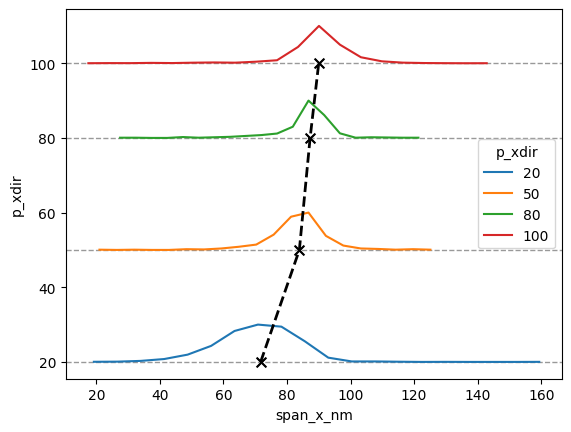

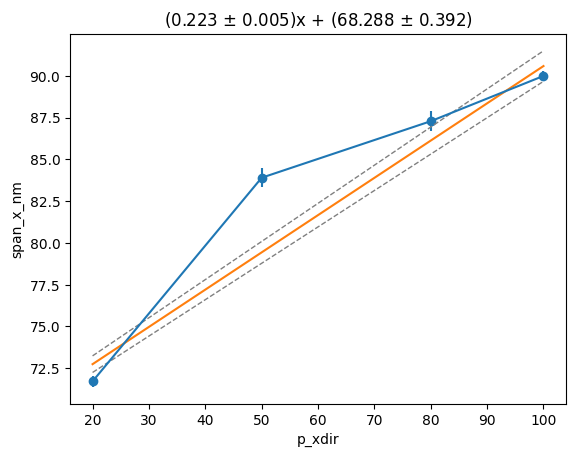

In [61]:
histo_and_fit(df['p_xdir'], df['span_x_nm'], xpts=[10 * x for x in range(20)], xlbl='p_xdir', ylbl='span_x_nm', bins=20)

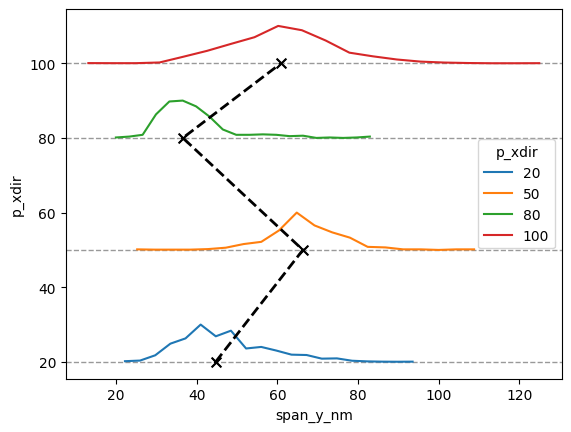

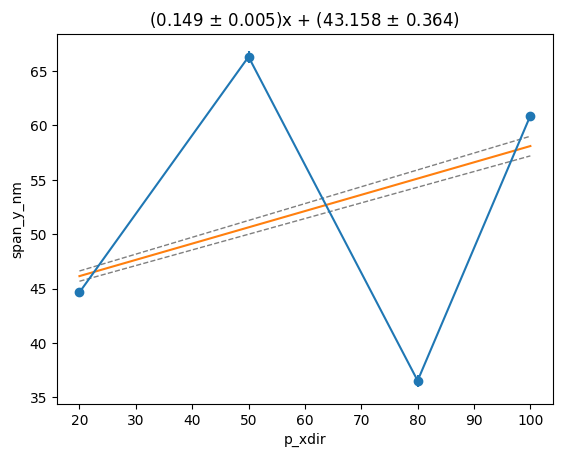

In [62]:
histo_and_fit(df['p_xdir'], df['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p_xdir', ylbl='span_y_nm', bins=20)

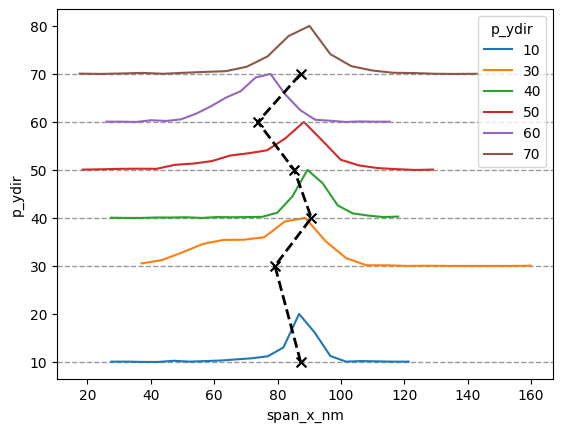

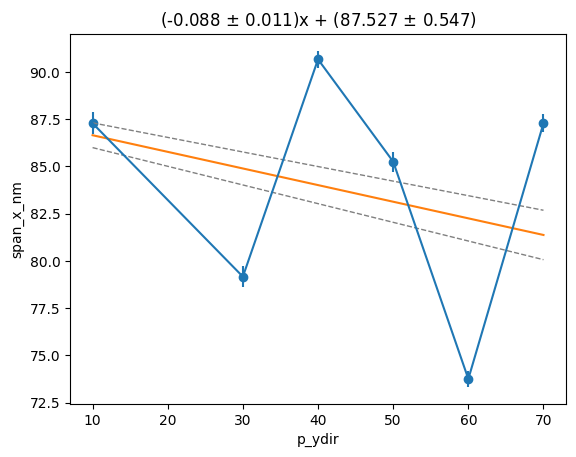

In [63]:
histo_and_fit(df['p_ydir'], df['span_x_nm'], xpts=[10 * x for x in range(20)], xlbl='p_ydir', ylbl='span_x_nm', bins=20)

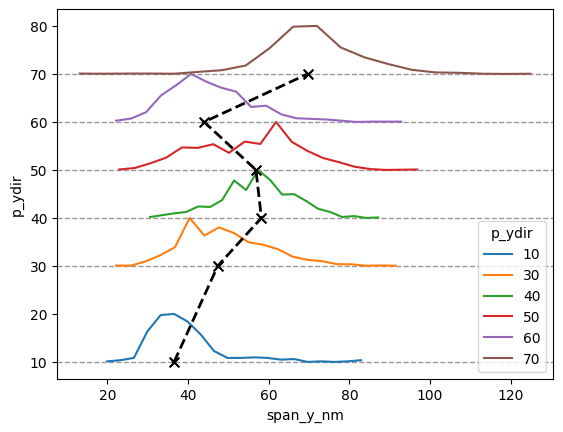

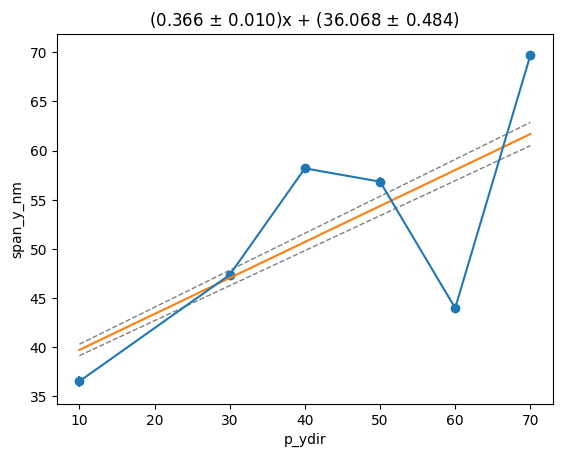

In [64]:
histo_and_fit(df['p_ydir'], df['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p_ydir', ylbl='span_y_nm', bins=20)

## Rectangle Size

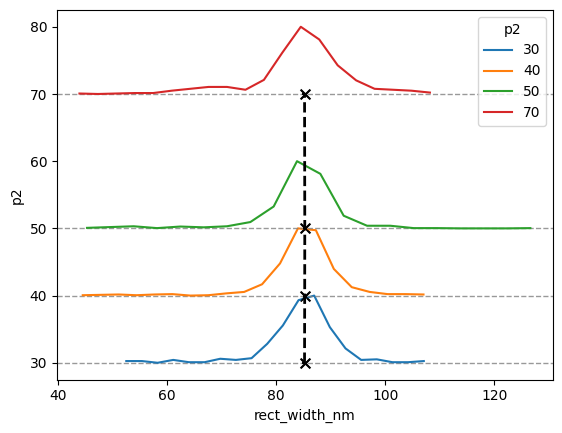

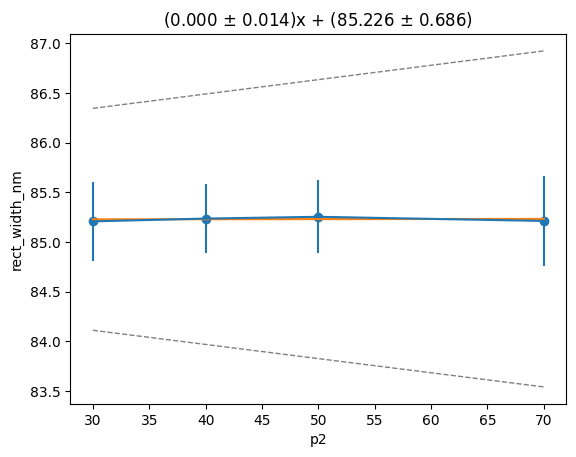

In [87]:
histo_and_fit(df['p2'], df['rect_width_nm'], xpts=[10 * x for x in range(20)], xlbl='p2', ylbl='rect_width_nm', bins=20)

In [89]:
np.unique(list(df['p1']))

array([100])

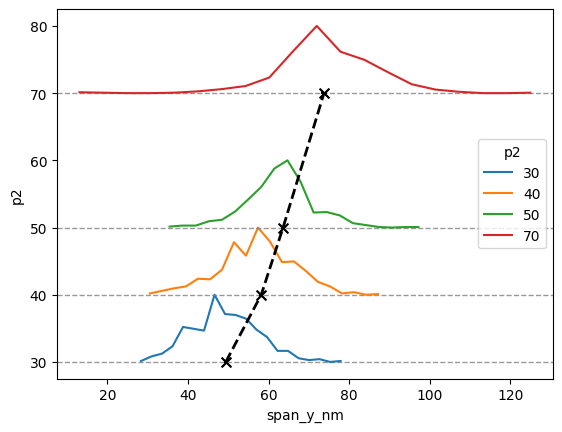

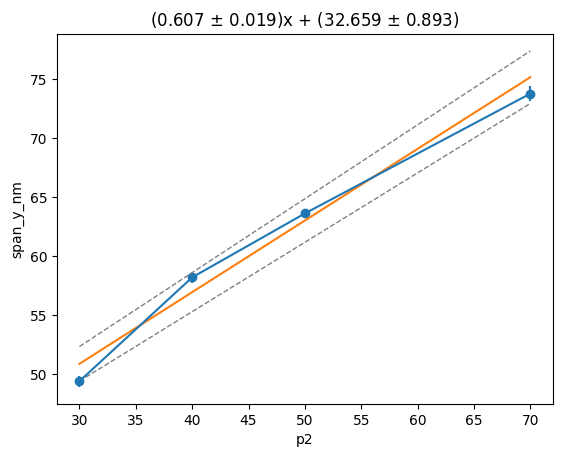

In [112]:
histo_and_fit(df['p2'], df['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p2', ylbl='span_y_nm', bins=20)


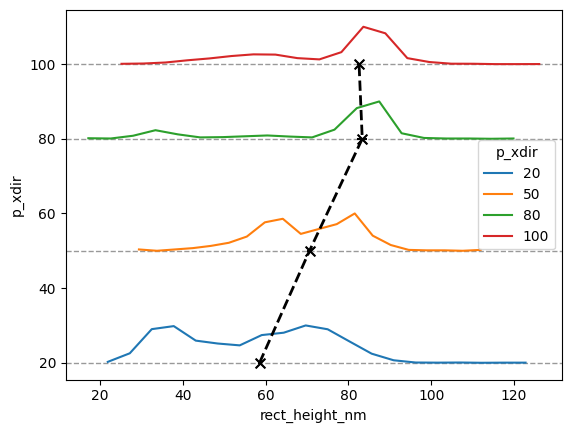

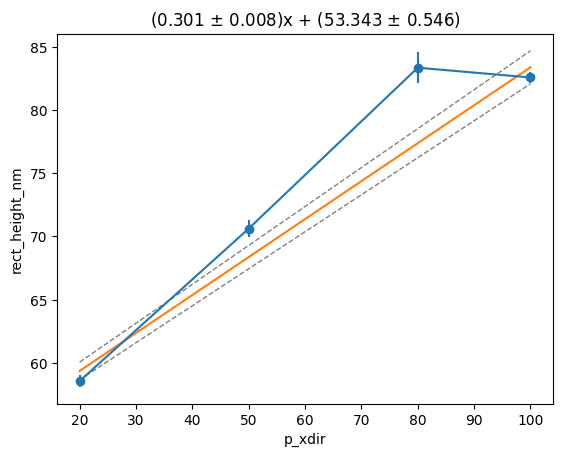

In [66]:
histo_and_fit(df['p_xdir'], df['rect_height_nm'], xpts=[10 * x for x in range(20)], xlbl='p_xdir', ylbl='rect_height_nm', bins=20)

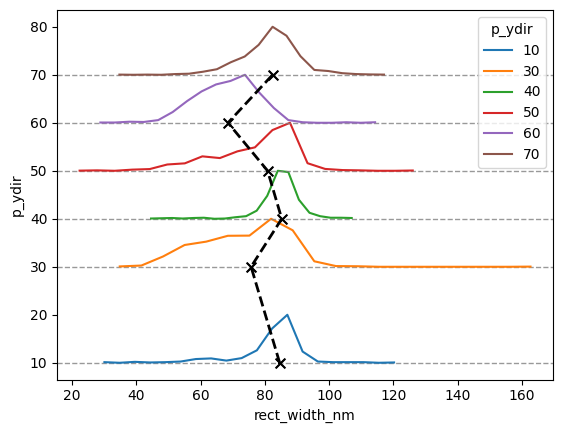

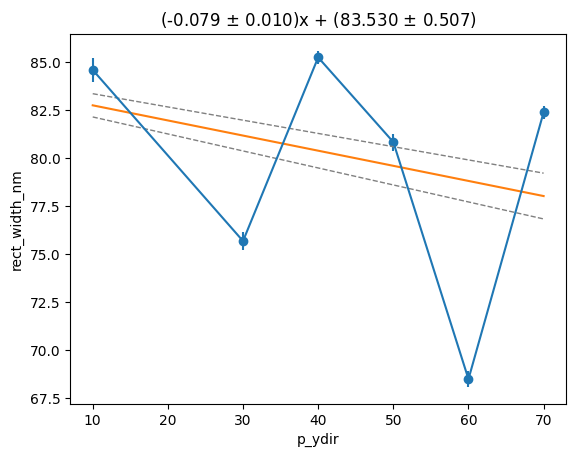

In [67]:
histo_and_fit(df['p_ydir'], df['rect_width_nm'], xpts=[10 * x for x in range(20)], xlbl='p_ydir', ylbl='rect_width_nm', bins=20)

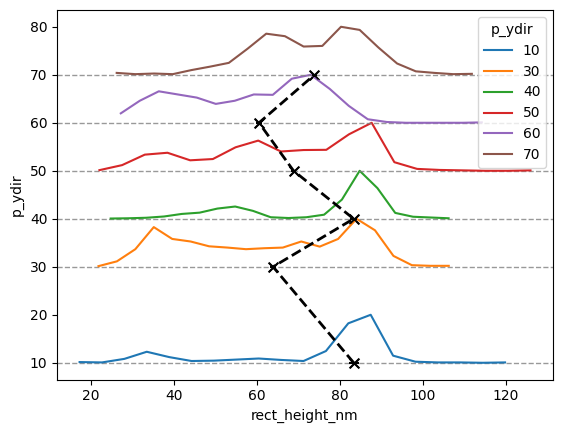

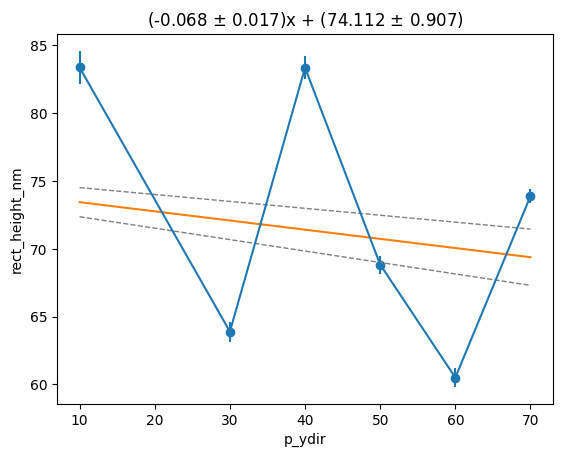

In [68]:
histo_and_fit(df['p_ydir'], df['rect_height_nm'], xpts=[10 * x for x in range(20)], xlbl='p_ydir', ylbl='rect_height_nm', bins=20)

In [80]:
srt = [list(df['p2'])[i] for i in range(len(df['p2'])) if list(df['p1'])[i] == 100]

# Short axis

In [92]:
import copy

In [95]:
dfsrt = copy.deepcopy(df)

In [96]:
dfsrt = dfsrt[(dfsrt['short_axis'] == 1)]

In [97]:
len(dfsrt)

2325

# Long Axis

In [100]:
file = r"F:\Data\LiuDimer\Sizes\res.csv"
dflong = pd.read_csv(file, delimiter=';')

In [101]:
len(dflong)


11075

In [103]:
dflong = dflong[(dflong['long_axis'] == 1)]


In [104]:
len(dflong)

6467

In [105]:
dflong = dflong[(dflong['conf'] > 0.8)]


In [106]:
len(dflong)

2782

In [107]:
dflong = dflong[(dflong['p2'] == 20)]


In [108]:
len(dflong)

2289

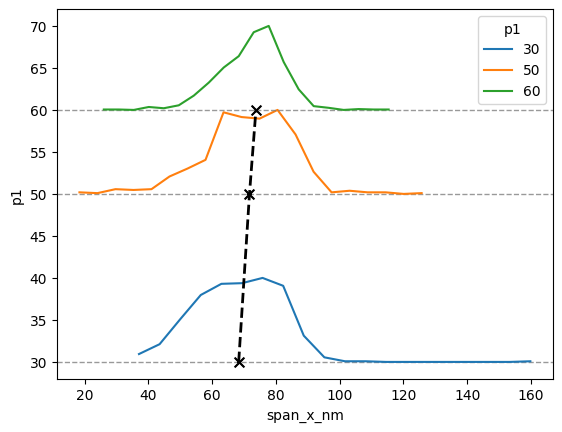

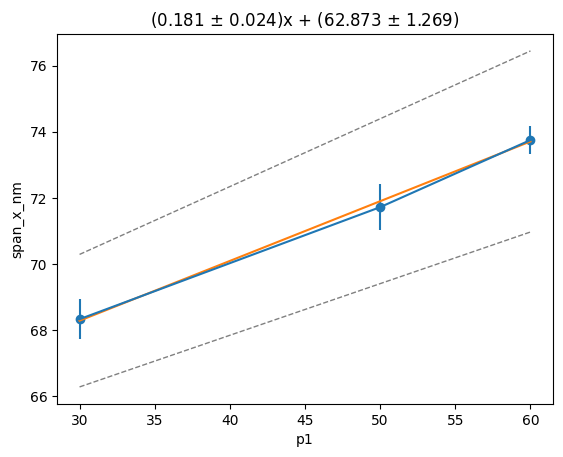

In [110]:
histo_and_fit(dflong['p1'], dflong['span_x_nm'], xpts=[10 * x for x in range(20)], xlbl='p1', ylbl='span_x_nm', bins=20)

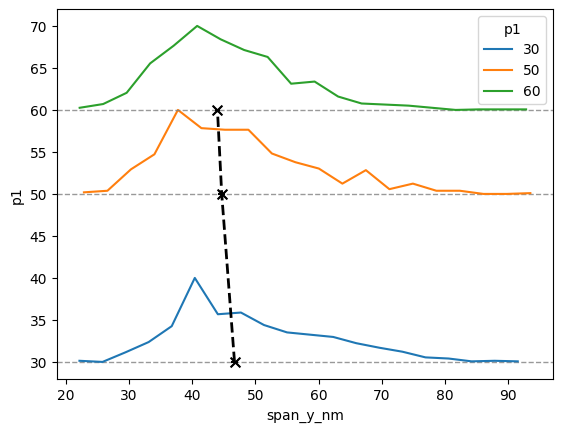

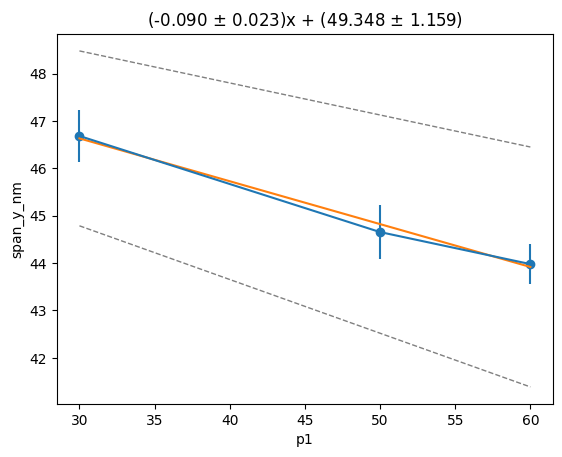

In [111]:
histo_and_fit(dflong['p1'], dflong['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p1', ylbl='span_y_nm', bins=20)


# Export Data

## Short Axis

In [113]:
file = r"F:\Data\LiuDimer\Sizes\res.csv"
df = pd.read_csv(file, delimiter=';')
df = df[(df['conf'] > 0.8)]
len(df)

5518

In [114]:
df = df[(df['p1'] == 100)]


In [115]:
len(df)

2325

In [117]:
sum(list(df['short_axis']))

2325

In [120]:
p2s = np.unique(df['p2'])
for p2 in p2s:
    outf = f'shortAxis_100x{p2}.csv'
    with open(outf, 'w') as f:
        f.write('span_x (nm) ;span_y (nm)\n')
        dfp = copy.deepcopy(df)
        dfp = dfp[dfp['p2'] == p2]
        for i in range(len(dfp)):
            f.write(f"{list(dfp['span_x_nm'])[i]};{list(dfp['span_y_nm'])[i]}\n")

## Long Axis

In [121]:
file = r"F:\Data\LiuDimer\Sizes\res.csv"
df = pd.read_csv(file, delimiter=';')
df = df[(df['conf'] > 0.8)]
len(df)

5518

In [122]:
df = df[(df['p2'] == 20)]


In [123]:
p1s = np.unique(df['p1'])
for p1 in p1s:
    outf = f'longAxis_{p1}x20.csv'
    with open(outf, 'w') as f:
        f.write('span_x (nm) ;span_y (nm)\n')
        dfp = copy.deepcopy(df)
        dfp = dfp[dfp['p1'] == p1]
        for i in range(len(dfp)):
            f.write(f"{list(dfp['span_x_nm'])[i]};{list(dfp['span_y_nm'])[i]}\n")